# Population-model adaptation sweep


In [10]:
import sys, pathlib, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

_SRC = pathlib.Path.cwd()
for _ in range(6):
    if (_SRC / "ProVoice").is_dir():
        break
    _SRC = _SRC.parent
sys.path.insert(0, str(_SRC))

# Imported, not reimplemented: the lookup must be the SAME rule here as in
# baseline_lookup.py, or "the gap to the lookup" is a gap to something else.
from ProVoice.training_scripts.blocked_stats import blocked_effects
from ProVoice.training_scripts.baseline_lookup import (
    best_constant, build_table, load_labels, predict,
)

%matplotlib inline
pd.set_option("display.width", 220)
warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = _SRC.parent
SWEEP_CSV = ROOT / "results/l2sp_sweep/l2sp_tau_sweep.csv"        # NEW backbone
PREV_CSV  = ROOT / "results/l2sp_sweep_fcd_extend/l2sp_tau_sweep.csv"  # previous, section 8
LABELS_CSV = ROOT / "data/study1_data/user_loa_labels.csv"
VAL_FRAC = 0.3        # MUST match the --val-frac the sweep ran with
K_CAP = 60
GRAD_OK = 1e-3        # sweep_l2sp_tau.GRAD_NORM_WARN

df = pd.read_csv(SWEEP_CSV, dtype={"pid": str})

In [11]:
# ---------------- the lookup, recomputed on the SWEEP's protocol

def lookup_on_sweep_protocol(labels_csv: pathlib.Path, ks, val_frac: float,
                             variant: str = "driver_function",
                             min_cell: int = 1) -> pd.DataFrame:
    """Per-(driver, function) lookup, scored exactly the way the sweep scores.

    support = the driver's first K segments; query = their chronologically last
    ``val_frac`` — the same split `sweep_l2sp_tau.sweep_driver` uses, so the two
    curves are measured on identical rows and can be subtracted.

    Returns one row per (pid, k) with set_mae and set_acc, matching the sweep's
    column names so a join is trivial.
    """
    lab = load_labels(labels_csv)
    out = []
    for pid, g in lab.groupby("participantid"):
        g = g.reset_index(drop=True)
        n = len(g)
        n_val = max(1, round(val_frac * n))
        pool, query = g.iloc[: n - n_val], g.iloc[n - n_val:]
        q_lv = np.stack(query["marks"].to_numpy())
        for k in ks:
            if k > len(pool):
                continue          # this driver has no such prefix; leave the cell empty
            table, driver_c = build_table(pool.iloc[:k], min_cell)
            if driver_c is None:
                continue
            pred, _ = predict(query, table, driver_c, variant)
            out.append({"pid": str(pid), "k": int(k),
                        "lk_set_mae": float(set_mae_(q_lv, pred)),
                        "lk_set_acc": float(set_acc_(q_lv, pred))})
    return pd.DataFrame(out)


# The metric functions the whole project uses; imported here rather than
# re-derived so "set-MAE" means one thing across every table in the thesis.
from ProVoice.models.train_XLSTM import set_accuracy as set_acc_, set_mae as set_mae_

KS = sorted(df.k.unique())
LK = lookup_on_sweep_protocol(LABELS_CSV, KS, VAL_FRAC)
print(f"lookup recomputed for {LK.pid.nunique()} drivers x {LK.k.nunique()} K values")

# Join on (pid, k): every comparison below is WITHIN a driver at a fixed K, which
# is what cancels driver difficulty (per-driver floors span ~0.5 to ~1.6).
M = df.merge(LK, on=["pid", "k"], how="left")
print(f"rows with a matched lookup value: {M.lk_set_mae.notna().mean():.1%}")

lookup recomputed for 12 drivers x 19 K values
rows with a matched lookup value: 100.0%


In [12]:
# ------------------------------------------------ shared plotting helpers

def _tau_colours(taus):
    cmap = plt.get_cmap("viridis")
    return {t: cmap(i / max(1, len(taus) - 1)) for i, t in enumerate(sorted(taus))}


def coverage(sub: pd.DataFrame) -> pd.Series:
    """Drivers contributing at each K. Above the cap only the long drivers have
    data, so the mean there is a different (and smaller) cohort — drawn, but the
    reader has to be able to see it."""
    return sub.groupby("k").pid.nunique()


def plot_vs_k(data: pd.DataFrame, value: str, ylabel: str, title: str,
              floor: float = None, floor_label: str = None,
              zero_line: bool = False, selected_tau: float = None,
              ax=None, min_drivers: int = None, agg: str = "mean",
              reference: pd.Series = None, reference_label: str = None):
    """One line per tau, K on x. The single drawing routine for all six panels.

    `min_drivers` shades the region where fewer than that many drivers contribute:
    past K=60 only the longest sessions have data, so the curve there is a
    different cohort rather than a continuation of the same one.

    `reference` is an optional Series indexed by K -- the deployable lookup -- drawn
    as a curve, because it improves with K as well and a flat line would misstate
    the comparison at exactly the K values that matter.

    `agg` is "mean" or "median". Both are worth looking at and they answer
    different questions. The MEAN is what `sweep_l2sp_tau` selects tau on, so it
    is the quantity that actually chose the shipped value. But per-driver set-MAE
    spans ~0.4 to ~2.2 here, so at n=12 one driver's excursion moves the mean by
    about a tenth of its own size -- the apparent dip-and-bump between K=16 and
    K=20 is a SINGLE driver (007: 1.122 -> 2.171), and vanishes to +0.008 with
    that driver removed. For reading a SHAPE the median is far more robust; for
    selecting on it, the mean is the pre-registered choice. Neither replaces the
    other.
    """
    ax = ax or plt.subplots(figsize=(7.5, 4.8))[1]
    taus = sorted(data.tau.unique())
    cols = _tau_colours(taus)
    for t in taus:
        c = data[data.tau == t].groupby("k")[value].agg(agg).sort_index()
        ax.plot(c.index, c.values, marker="o", ms=3, color=cols[t],
                lw=2.0 if (selected_tau and float(t) == float(selected_tau)) else 1.0,
                label=f"tau={t:g}" + ("  (selected)" if selected_tau
                                      and float(t) == float(selected_tau) else ""))
    if floor is not None:
        ax.axhline(floor, ls="--", c="0.35", lw=1.2, label=floor_label)
    if reference is not None:
        # The deployable lookup, drawn as a CURVE rather than a horizontal floor:
        # it improves with K too, so a flat reference line would understate it at
        # large K and flatter the model. Heavy black so it reads as the thing to
        # beat rather than as one more tau.
        r = reference.sort_index()
        ax.plot(r.index, r.values, c="k", lw=2.6, ls="-", marker="s", ms=3.5,
                zorder=5, label=reference_label or "lookup (driver x function)")
    if zero_line:
        ax.axhline(0, c="k", lw=1.2)
    cov = coverage(data)
    if min_drivers:
        thin = cov[cov < min_drivers]
        if len(thin):
            ax.axvspan(thin.index.min(), cov.index.max(), color="0.85", alpha=.6, zorder=0)
    ax.axvline(K_CAP, ls=":", c="0.6", lw=1.0)
    ax.set_xlabel("personalization segments K  (20 s each)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=.3)
    ax.legend(fontsize=7, ncol=2)
    return ax

---
## 1. set-MAE vs K


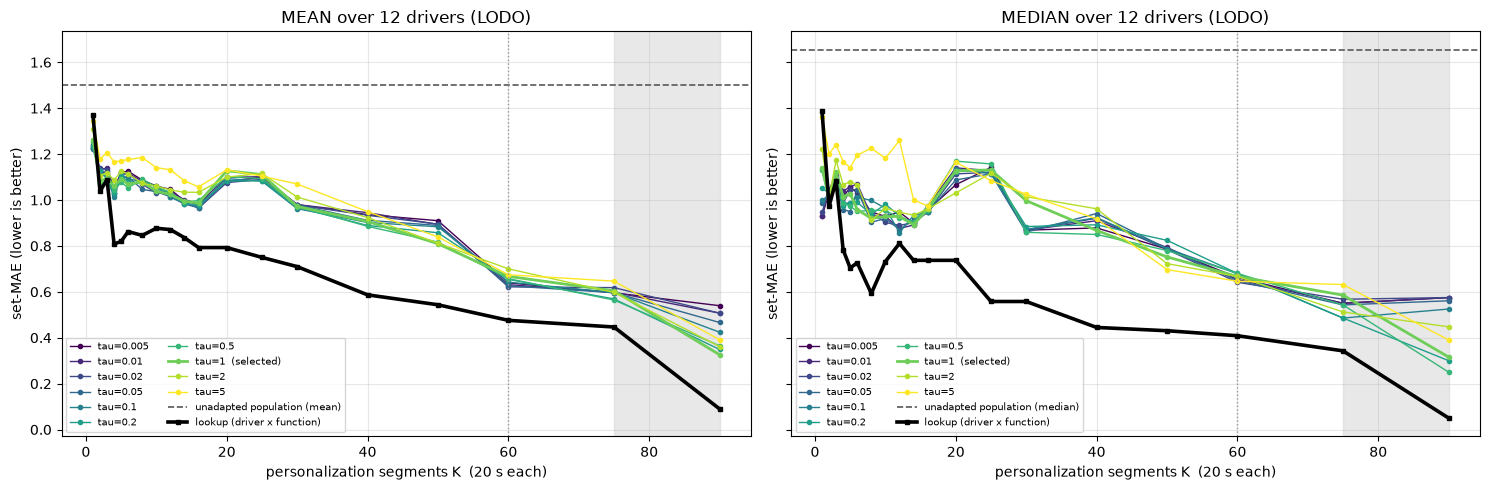

shaded: fewer than 12 drivers contribute (only the longest sessions reach K>60)


**mean vs median at tau=0.5** — a large gap means a skewed driver distribution at that K

,mean,median,mean - median
k,,,
1,1.253,1.129,0.125
2,1.074,0.999,0.075
3,1.075,1.064,0.011
4,1.043,0.986,0.057
5,1.077,0.973,0.104
6,1.053,0.950,0.103
8,1.091,0.955,0.136
10,1.056,0.955,0.101
12,1.033,0.920,0.113


In [13]:
SEL_TAU = 1.0      # results/l2sp_sweep/selected_tau.json, blocked estimator
BEST_TAU = float(df[df.k <= K_CAP].groupby(["tau", "pid"]).set_mae.mean()
                 .groupby("tau").mean().idxmin())
# MEAN and MEDIAN side by side. If a feature appears in one and not the other it
# is one driver, not a property of the cohort -- which is exactly what the
# K=16->20 bump turned out to be.
# The lookup aggregated the SAME way as the model curve in each panel -- a mean
# curve must be compared against a mean, a median against a median.
LK_MAE = {a: M.groupby("k").lk_set_mae.agg(a) for a in ("mean", "median")}
LK_ACC = {a: M.groupby("k").lk_set_acc.agg(a) for a in ("mean", "median")}

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, agg in zip(axes, ("mean", "median")):
    plot_vs_k(df, "set_mae", "set-MAE (lower is better)",
              f"{agg.upper()} over {df.pid.nunique()} drivers (LODO)",
              floor=df.base_set_mae.agg(agg), floor_label=f"unadapted population ({agg})",
              selected_tau=SEL_TAU, ax=ax, min_drivers=12, agg=agg,
              reference=LK_MAE[agg], reference_label="lookup (driver x function)")
plt.tight_layout(); plt.show()
print("shaded: fewer than 12 drivers contribute (only the longest sessions reach K>60)")

# The gap between the two aggregations, at the best tau, is a direct read on how
# much any given point is being driven by one driver.
b = df[df.tau == BEST_TAU]
cmp = pd.DataFrame({"mean": b.groupby("k").set_mae.mean(),
                    "median": b.groupby("k").set_mae.median()})
cmp["mean - median"] = cmp["mean"] - cmp["median"]
display(Markdown(f"**mean vs median at tau={BEST_TAU:g}** — a large gap means a "
                 f"skewed driver distribution at that K"))
display(cmp.round(3))

---
## 2. set-MAE vs K minus lookup

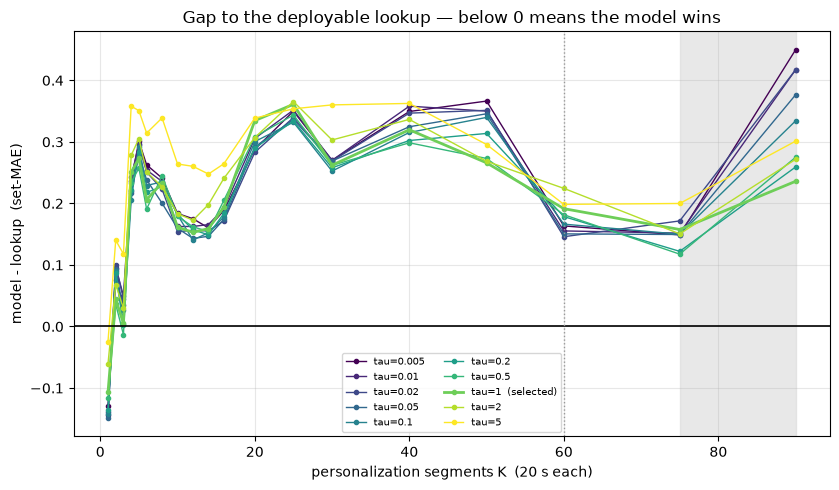

**Gap at tau=0.5 (best by mean)**

,model,lookup,gap,n
k,,,,
1,1.253,1.370,-0.117,12
2,1.074,1.038,0.036,12
3,1.075,1.089,-0.013,12
4,1.043,0.809,0.234,12
5,1.077,0.819,0.257,12
6,1.053,0.862,0.191,12
8,1.091,0.846,0.245,12
10,1.056,0.877,0.179,12
12,1.033,0.871,0.162,12


gap trend: +0.00320 per label  ->  not closing
Linear extrapolation of a learning curve is optimistic; the collected budget reaches K~60 (95 at most), so any crossover beyond that is untestable here.


In [14]:
M["gap_mae"] = M.set_mae - M.lk_set_mae      # >0 : lookup better

fig, ax = plt.subplots(figsize=(8.5, 5))
plot_vs_k(M.dropna(subset=["gap_mae"]), "gap_mae",
          "model - lookup  (set-MAE)",
          "Gap to the deployable lookup — below 0 means the model wins",
          zero_line=True, selected_tau=SEL_TAU, ax=ax, min_drivers=12)
plt.tight_layout(); plt.show()

g = M[(M.tau == BEST_TAU) & (M.k <= K_CAP)].dropna(subset=["gap_mae"])
tbl = g.groupby("k").agg(model=("set_mae", "mean"), lookup=("lk_set_mae", "mean"),
                         gap=("gap_mae", "mean"), n=("pid", "nunique"))
display(Markdown(f"**Gap at tau={BEST_TAU:g} (best by mean)**"))
display(tbl.round(3))
sl = np.polyfit(tbl.index.astype(float), tbl["gap"].values, 1)
print(f"gap trend: {sl[0]:+.5f} per label"
      + (f"  ->  extrapolates to zero at K={-sl[1]/sl[0]:.0f}" if sl[0] < 0
         else "  ->  not closing"))
print("Linear extrapolation of a learning curve is optimistic; the collected budget "
      "reaches K~60 (95 at most), so any crossover beyond that is untestable here.")

---
## 3. The same two views in set-ACCURACY

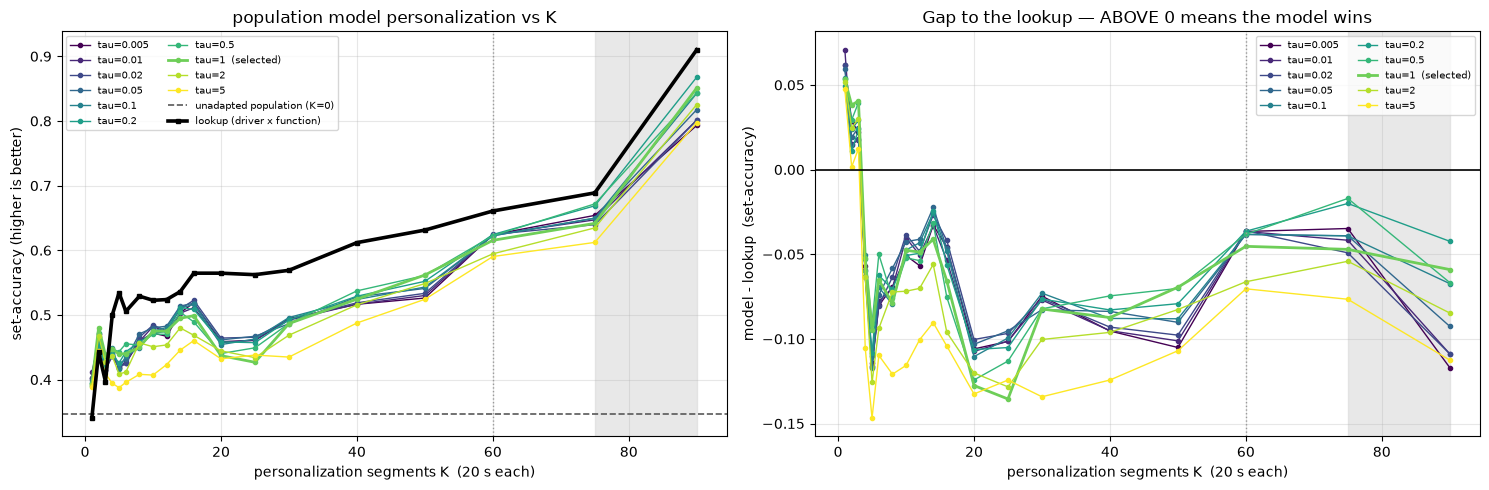

**Accuracy gap at tau=0.5**

,model,lookup,gap
k,,,
1,0.394,0.341,0.054
2,0.472,0.442,0.029
3,0.437,0.397,0.040
4,0.447,0.500,-0.053
5,0.443,0.534,-0.091
6,0.455,0.506,-0.050
8,0.453,0.529,-0.076
10,0.471,0.523,-0.052
12,0.470,0.524,-0.054


accuracy gap trend: -0.00105 per label  ->  not closing


In [15]:
M["gap_acc"] = M.set_acc - M.lk_set_acc     # >0 : MODEL better (higher is better)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_vs_k(df, "set_acc", "set-accuracy (higher is better)",
          "population model personalization vs K", floor=df.base_set_acc.mean(),
          floor_label="unadapted population (K=0)", selected_tau=SEL_TAU,
          ax=axes[0], min_drivers=12,
          reference=LK_ACC["mean"], reference_label="lookup (driver x function)")
plot_vs_k(M.dropna(subset=["gap_acc"]), "gap_acc",
          "model - lookup  (set-accuracy)",
          "Gap to the lookup — ABOVE 0 means the model wins",
          zero_line=True, selected_tau=SEL_TAU, ax=axes[1], min_drivers=12)
plt.tight_layout(); plt.show()

ga = M[(M.tau == BEST_TAU) & (M.k <= K_CAP)].dropna(subset=["gap_acc"])
t2 = ga.groupby("k").agg(model=("set_acc", "mean"), lookup=("lk_set_acc", "mean"),
                         gap=("gap_acc", "mean"))
display(Markdown(f"**Accuracy gap at tau={BEST_TAU:g}**"))
display(t2.round(3))
sl2 = np.polyfit(t2.index.astype(float), t2["gap"].values, 1)
print(f"accuracy gap trend: {sl2[0]:+.5f} per label"
      + (f"  ->  reaches zero at K={-sl2[1]/sl2[0]:.0f}" if sl2[0] > 0 else "  ->  not closing"))

---
## 4. Per-driver curves at the best tau


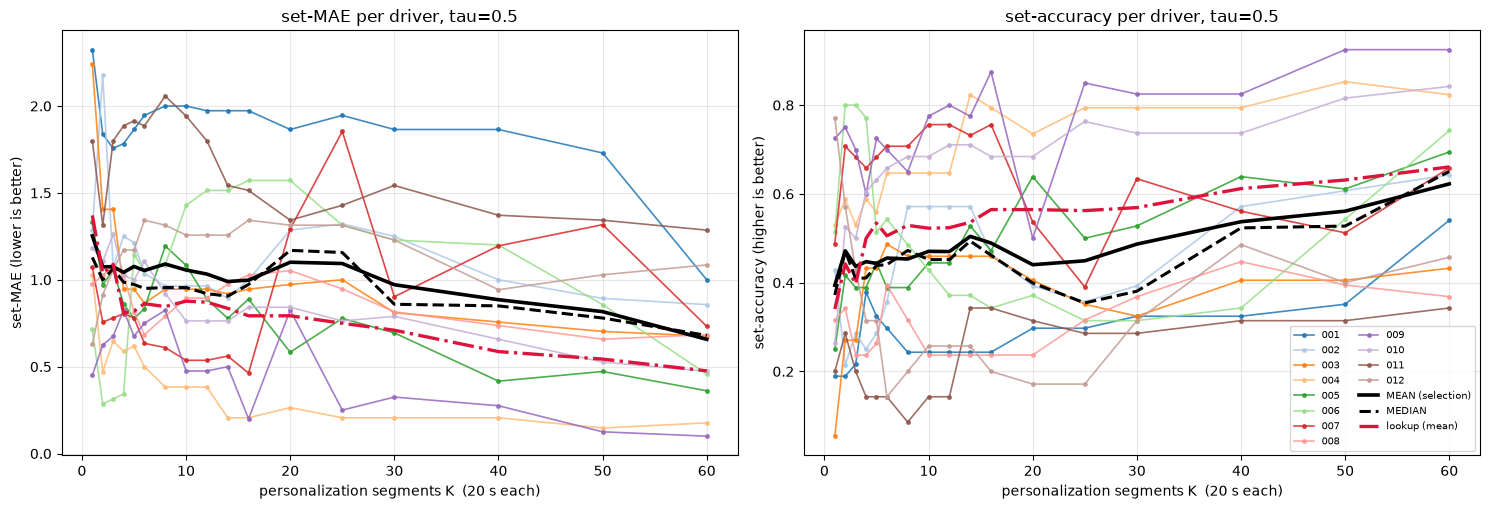

**Per-driver trend over K=20-60 at tau=0.5** (negative mae_slope = improving)

,pid,mae@20,mae@60,mae_slope,acc@20,acc@60,acc_slope,floor(K=0)
0,006,1.5714,0.4571,-0.0245,0.3714,0.7429,0.0097,0.6286
1,001,1.8649,1.0000,-0.0187,0.2973,0.5405,0.0051,1.7838
2,007,1.2927,0.7317,-0.0140,0.5366,0.6585,0.0030,2.5366
3,009,0.8250,0.1000,-0.0131,0.5000,0.9250,0.0075,0.6500
4,002,1.2857,0.8571,-0.0130,0.3929,0.6429,0.0077,1.7143
5,010,0.8421,0.4737,-0.0095,0.6842,0.8421,0.0033,1.7895
6,008,1.0526,0.6842,-0.0092,0.2368,0.3684,0.0029,1.3684
7,005,0.5833,0.3611,-0.0085,0.6389,0.6944,0.0029,2.0556
8,003,0.9730,0.6757,-0.0082,0.4054,0.4324,0.0016,1.5946
9,012,1.3143,1.0857,-0.0076,0.1714,0.4571,0.0076,0.8571


improving on set-MAE : 12/12 drivers
improving on set-acc : 12/12 drivers
per-driver set-MAE at K=60 spans 0.10 to 1.29 — the spread the pooled curve averages away


In [16]:
# ------------------------------- per-driver curves at the best tau

def plot_per_driver(data: pd.DataFrame, tau: float, k_max: int = K_CAP):
    """One line per driver for set-MAE and set-accuracy, at a single tau.

    Restricted to K <= k_max because past 60 only three drivers have data, and a
    line that stops early reads as a driver who got worse rather than one who ran
    out of labels.

    The cohort mean and median are drawn over the top in black so the individual
    spread can be compared against the number the tau selection actually used.
    """
    b = data[(data.tau == tau) & (data.k <= k_max)]
    if b.empty:
        print("(no rows at that tau)")
        return
    pids = sorted(b.pid.unique())
    cmap = plt.get_cmap("tab20")
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
    for j, (col, ylab, better) in enumerate(
            (("set_mae", "set-MAE", "lower"), ("set_acc", "set-accuracy", "higher"))):
        ax = axes[j]
        for i, pid in enumerate(pids):
            g = b[b.pid == pid].sort_values("k")
            ax.plot(g.k, g[col], color=cmap(i % 20), lw=1.2, marker="o", ms=2.5,
                    alpha=.85, label=pid)
        m = b.groupby("k")[col].mean()
        md_ = b.groupby("k")[col].median()
        ax.plot(m.index, m.values, c="k", lw=2.6, label="MEAN (selection)")
        ax.plot(md_.index, md_.values, c="k", lw=2.2, ls="--", label="MEDIAN")
        # The lookup's cohort mean, so the per-driver spread can be read against
        # the thing the model has to beat rather than only against itself.
        lk_col = "lk_set_mae" if col == "set_mae" else "lk_set_acc"
        lkm = M[(M.tau == tau) & (M.k <= k_max)].groupby("k")[lk_col].mean()
        ax.plot(lkm.index, lkm.values, c="crimson", lw=2.4, ls="-.",
                label="lookup (mean)")
        ax.set_xlabel("personalization segments K  (20 s each)")
        ax.set_ylabel(f"{ylab} ({better} is better)")
        ax.set_title(f"{ylab} per driver, tau={tau:g}")
        ax.grid(alpha=.3)
    axes[1].legend(fontsize=7, ncol=2, loc="best")
    plt.tight_layout(); plt.show()


plot_per_driver(df, BEST_TAU)

# Who improves and who does not. `slope` is a straight-line fit over the
# DEPLOYABLE range only: below ~K=20 both the model and the lookup are still
# degenerate, and including that region makes every slope look positive.
b = df[(df.tau == BEST_TAU) & (df.k >= 20) & (df.k <= K_CAP)]
rows = []
for pid, g in b.groupby("pid"):
    g = g.sort_values("k")
    rows.append({"pid": pid,
                 "mae@20": g.set_mae.iloc[0], "mae@60": g.set_mae.iloc[-1],
                 "mae_slope": np.polyfit(g.k.astype(float), g.set_mae, 1)[0],
                 "acc@20": g.set_acc.iloc[0], "acc@60": g.set_acc.iloc[-1],
                 "acc_slope": np.polyfit(g.k.astype(float), g.set_acc, 1)[0],
                 "floor(K=0)": g.base_set_mae.iloc[0]})
per = pd.DataFrame(rows).sort_values("mae_slope").reset_index(drop=True)
display(Markdown(f"**Per-driver trend over K=20-60 at tau={BEST_TAU:g}** "
                 f"(negative mae_slope = improving)"))
display(per.round(4))
print(f"improving on set-MAE : {(per.mae_slope < 0).sum()}/{len(per)} drivers")
print(f"improving on set-acc : {(per.acc_slope > 0).sum()}/{len(per)} drivers")
print(f"per-driver set-MAE at K=60 spans {per['mae@60'].min():.2f} to "
      f"{per['mae@60'].max():.2f} — the spread the pooled curve averages away")

### One panel per driver


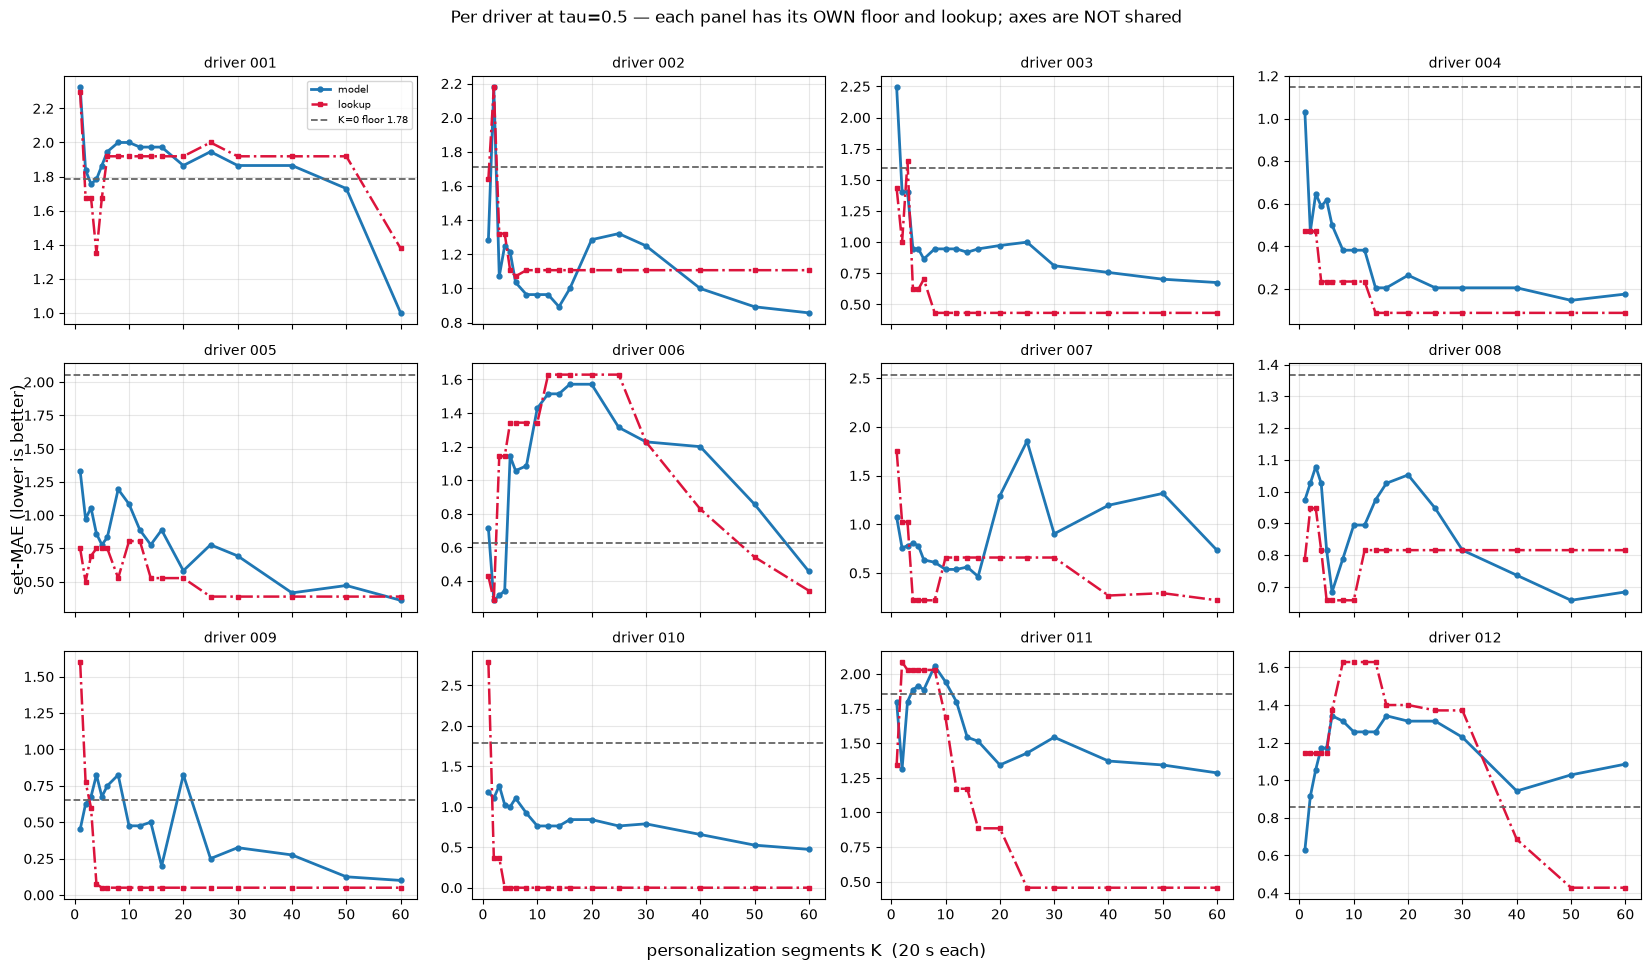

**Per driver at tau=0.5, against its own references**

,floor,model@60,lookup@60,best_K,model@best,beats_floor,beats_lookup
pid,,,,,,,
001,1.784,1.000,1.378,60,1.000,True,True
002,1.714,0.857,1.107,60,0.857,True,True
003,1.595,0.676,0.432,60,0.676,True,False
004,1.147,0.176,0.088,50,0.147,True,False
005,2.056,0.361,0.389,60,0.361,True,True
006,0.629,0.457,0.343,2,0.286,True,False
007,2.537,0.732,0.220,16,0.463,True,False
008,1.368,0.684,0.816,50,0.658,True,True
009,0.650,0.100,0.050,60,0.100,True,False


beat their own K=0 floor at K=60 : 11/12
beat their own lookup at K=60    : 4/12
drivers whose best K is below 20 : 3/12 -- see section 5 on why per-driver minima are not reliable at ~36 query segments per cell


In [17]:
def plot_driver_panels(data: pd.DataFrame, tau: float, k_max: int = K_CAP,
                       ncol: int = 4):
    """One axis per driver: model, that driver's lookup, that driver's K=0 floor."""
    b = data[(data.tau == tau) & (data.k <= k_max)]
    if b.empty:
        print("(no rows at that tau)")
        return
    pids = sorted(b.pid.unique())
    nrow = int(np.ceil(len(pids) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.2 * nrow), sharex=True)
    for ax, pid in zip(np.ravel(axes), pids):
        g = b[b.pid == pid].sort_values("k")
        ax.plot(g.k, g.set_mae, color="tab:blue", lw=2, marker="o", ms=3.5,
                label="model")
        lk = M[(M.tau == tau) & (M.k <= k_max) & (M.pid == pid)].sort_values("k")
        if not lk.empty:
            ax.plot(lk.k, lk.lk_set_mae, color="crimson", lw=1.8, ls="-.", marker="s",
                    ms=3, label="lookup")
        ax.axhline(g.base_set_mae.iloc[0], ls="--", c="0.4", lw=1.3,
                   label=f"K=0 floor {g.base_set_mae.iloc[0]:.2f}")
        ax.set_title(f"driver {pid}", fontsize=10)
        ax.grid(alpha=.3)
    for ax in np.ravel(axes)[len(pids):]:
        ax.axis("off")
    np.ravel(axes)[0].legend(fontsize=7)
    fig.supxlabel("personalization segments K  (20 s each)")
    fig.supylabel("set-MAE (lower is better)")
    fig.suptitle(f"Per driver at tau={tau:g} — each panel has its OWN floor and lookup; "
                 f"axes are NOT shared", y=1.0)
    plt.tight_layout(); plt.show()


plot_driver_panels(df, BEST_TAU)

# Where each driver ends up relative to ITS OWN two references, which the pooled
# curve cannot show: beating the floor and beating the lookup are different bars,
# and a driver can clear one without the other.
b = df[(df.tau == BEST_TAU) & (df.k <= K_CAP)]
rows = []
for pid, g in b.groupby("pid"):
    g = g.sort_values("k")
    lk = M[(M.tau == BEST_TAU) & (M.k <= K_CAP) & (M.pid == pid)].sort_values("k")
    best_k = int(g.loc[g.set_mae.idxmin(), "k"])
    rows.append({"pid": pid,
                 "floor": g.base_set_mae.iloc[0],
                 "model@60": g.set_mae.iloc[-1],
                 "lookup@60": lk.lk_set_mae.iloc[-1] if not lk.empty else np.nan,
                 "best_K": best_k, "model@best": g.set_mae.min(),
                 "beats_floor": g.set_mae.iloc[-1] < g.base_set_mae.iloc[0],
                 "beats_lookup": (not lk.empty
                                  and g.set_mae.iloc[-1] < lk.lk_set_mae.iloc[-1])})
t = pd.DataFrame(rows).set_index("pid")
display(Markdown(f"**Per driver at tau={BEST_TAU:g}, against its own references**"))
display(t.round(3))
print(f"beat their own K=0 floor at K=60 : {t.beats_floor.sum()}/{len(t)}")
print(f"beat their own lookup at K=60    : {t.beats_lookup.sum()}/{len(t)}")
print(f"drivers whose best K is below 20 : {(t.best_K < 20).sum()}/{len(t)} "
      f"-- see section 5 on why per-driver minima are not reliable at ~36 query "
      f"segments per cell")

---
## 6. Plain head vs FCD-augmented head


[plain] no embed_fcd column (run predates it) — trusting the path. This is exactly the ambiguity the column was added to remove.
[fcd] no embed_fcd column (run predates it) — trusting the path. This is exactly the ambiguity the column was added to remove.
[check] K=0 floor agrees to 0.00e+00 -> same checkpoints and tail
[check] shared taus: [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0]

1526 paired cells over 12 drivers, 7 taus, 19 K values
  set-MAE  FCD - plain = -0.0196 +/- 0.0023 (t=-8.7); FCD better in 44% of cells
  set-acc  FCD - plain = +0.0057 +/- 0.0009 (t=+6.2); FCD better in 31% of cells


**FCD advantage by K** (negative d_mae / positive d_acc = FCD better)

,d_mae,d_acc,n
k,,,
1,-0.0088,0.0006,84
2,-0.0157,0.0056,84
3,-0.0024,-0.0019,84
4,0.0007,-0.0002,84
5,0.0107,-0.0032,84
6,0.0038,0.0006,84
8,-0.0056,0.0010,84
10,-0.0080,0.0003,84
12,-0.0246,0.0058,84


trend in the MAE advantage: -0.00051 per label  -> FCD helps MORE as labels accumulate


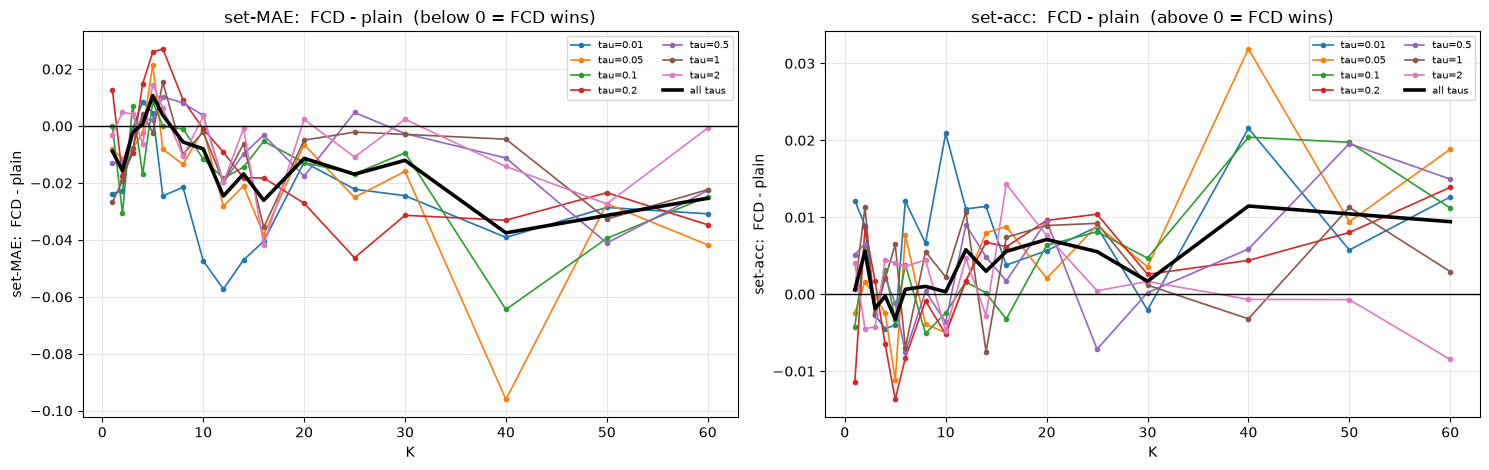

In [18]:
# ------------------------- paired comparison: plain vs FCD-augmented

# Set these to the two runs that differ ONLY in --embed-fcd. The FCD side is the
# extended sweep; point PLAIN_CSV at the matching plain run when it lands.
# NOTE both of these are PREVIOUS-backbone runs: the current sweep was
# fcd-only, so there is no plain counterpart on the new checkpoints. The
# FCD effect measured here therefore describes the OLD population model.
PLAIN_CSV = ROOT / "results/l2sp_sweep_plain/l2sp_tau_sweep.csv"
FCD_CSV   = ROOT / "results/l2sp_sweep_fcd_extend/l2sp_tau_sweep.csv"


def load_arm_csv(path: pathlib.Path, expect_fcd: int, name: str):
    """One stage-3 CSV, with its embed_fcd setting VERIFIED where possible."""
    if not path.exists():
        print(f"[{name}] not found: {path}")
        return None
    d = pd.read_csv(path, dtype={"pid": str})
    if "embed_fcd" in d.columns:
        got = sorted(d.embed_fcd.dropna().unique())
        if got != [expect_fcd]:
            print(f"[{name}] WARNING: file says embed_fcd={got}, expected "
                  f"[{expect_fcd}] — the paths are probably swapped.")
        else:
            print(f"[{name}] embed_fcd={expect_fcd} confirmed from the file "
                  f"(head_in={sorted(d.head_in.unique()) if 'head_in' in d else '?'})")
    else:
        print(f"[{name}] no embed_fcd column (run predates it) — trusting the path. "
              f"This is exactly the ambiguity the column was added to remove.")
    return d


A = load_arm_csv(PLAIN_CSV, 0, "plain")
B = load_arm_csv(FCD_CSV, 1, "fcd")

if A is None or B is None:
    print("\nOne of the two runs is missing — section skipped. Produce both with:")
    print("  sweep_l2sp_tau --outdir results/l2sp_sweep_plain --steps 6000")
    print("  sweep_l2sp_tau --outdir results/l2sp_sweep_fcd   --steps 6000 --embed-fcd")
    print("They must share the SAME LODO checkpoints and --val-frac, or the pairing "
          "is not a pairing.")
else:
    # VALIDITY, checked rather than assumed. Two runs are only paired if they
    # adapted from the same population models and scored on the same segments;
    # the K=0 floor is the signature of both, since it is the untouched head on
    # the evaluation tail. A mismatch means one of them used different LODO
    # checkpoints or a different --val-frac, and the difference would then be
    # attributed to the head width.
    fl = (A.groupby("pid").base_set_mae.first()
          - B.groupby("pid").base_set_mae.first()).abs().max()
    print(f"[check] K=0 floor agrees to {fl:.2e} "
          + ("-> same checkpoints and tail" if fl < 1e-9
             else "-> DIFFERENT setup; the comparison is NOT clean"))

    shared_tau = sorted(set(A.tau) & set(B.tau))
    print(f"[check] shared taus: {shared_tau or 'NONE'}"
          + ("" if len(shared_tau) >= 3 else
             "  <- thin; the per-tau breakdown will be noisy"))
    if not shared_tau:
        print("The two runs share no tau value, so nothing can be paired. Re-run the "
              "plain arm on the same --taus grid as the FCD one.")
        raise SystemExit
    A, B = A[A.tau.isin(shared_tau)], B[B.tau.isin(shared_tau)]

    key = ["pid", "tau", "k"]
    P = (A[key + ["set_mae", "set_acc"]]
         .merge(B[key + ["set_mae", "set_acc"]], on=key, suffixes=("_plain", "_fcd")))
    P["d_mae"] = P.set_mae_fcd - P.set_mae_plain      # <0 : FCD better
    P["d_acc"] = P.set_acc_fcd - P.set_acc_plain      # >0 : FCD better
    print(f"\n{len(P)} paired cells over {P.pid.nunique()} drivers, "
          f"{P.tau.nunique()} taus, {P.k.nunique()} K values")

    def paired(x, better_negative=True):
        se = x.std(ddof=1) / np.sqrt(len(x))
        return x.mean(), se, (x.mean() / se if se else np.nan)

    for nm, col, negbetter in (("set-MAE", "d_mae", True), ("set-acc", "d_acc", False)):
        m, se, t = paired(P[col])
        win = (P[col] < 0).mean() if negbetter else (P[col] > 0).mean()
        print(f"  {nm:8} FCD - plain = {m:+.4f} +/- {se:.4f} (t={t:+.1f}); "
              f"FCD better in {win:.0%} of cells")

    # DOES IT HELP MORE AT LARGE K? The reason for pairing per cell rather than
    # only in aggregate: the mechanism predicts a trend, not just a mean.
    byk = P[P.k <= K_CAP].groupby("k").agg(
        d_mae=("d_mae", "mean"), d_acc=("d_acc", "mean"), n=("pid", "size"))
    display(Markdown("**FCD advantage by K** (negative d_mae / positive d_acc = FCD better)"))
    display(byk.round(4))
    sl = np.polyfit(byk.index.astype(float), byk.d_mae.values, 1)[0]
    print(f"trend in the MAE advantage: {sl:+.5f} per label"
          + ("  -> FCD helps MORE as labels accumulate" if sl < 0
             else "  -> the advantage does not grow with K"))

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
    for ax, col, ylab in ((axes[0], "d_mae", "set-MAE:  FCD - plain"),
                          (axes[1], "d_acc", "set-acc:  FCD - plain")):
        for tau in sorted(P.tau.unique()):
            c = P[(P.tau == tau) & (P.k <= K_CAP)].groupby("k")[col].mean()
            ax.plot(c.index, c.values, lw=1.2, marker="o", ms=3, label=f"tau={tau:g}")
        allk = P[P.k <= K_CAP].groupby("k")[col].mean()
        ax.plot(allk.index, allk.values, c="k", lw=2.6, label="all taus")
        ax.axhline(0, c="k", lw=1.0)
        ax.set_xlabel("K"); ax.set_ylabel(ylab); ax.grid(alpha=.3)
        ax.set_title(ylab + ("  (below 0 = FCD wins)" if col == "d_mae"
                             else "  (above 0 = FCD wins)"))
        ax.legend(fontsize=7, ncol=2)
    plt.tight_layout(); plt.show()